# CE49X Lab 2: Is Wave Energy Worth the Investment?
## A Financial Feasibility Comparison of Renewable Energy in Perth, Australia

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

## Background

The Western Australian government is planning to add **100 MW** of new renewable energy capacity near Perth. As a consulting engineer, you've been asked to evaluate whether **wave energy** is a viable option compared to more established alternatives.

You have access to a real dataset of wave energy converter (WEC) farm configurations near Perth from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/882/large-scale+wave+energy+farm). The dataset (`WEC_Perth_49.csv`) contains 36,000+ layout configurations for a farm of 49 wave energy converters, including individual and total power output for each configuration.

Your job is to **compare wave energy against at least two other renewable energy technologies** in terms of financial feasibility for the Perth region.

## Hints

- **LCOE formula:**

$$\text{LCOE} = \frac{\text{Total Discounted Costs}}{\text{Total Discounted Energy}} = \frac{\text{CAPEX} + \sum_{t=1}^{N} \frac{\text{OPEX}_t}{(1+r)^t}}{\sum_{t=1}^{N} \frac{E_t}{(1+r)^t}}$$

  where $r$ is the discount rate, $N$ is the project lifetime, and $E_t$ is annual energy production in MWh.

- **Annual energy production:** $E = \text{Capacity (kW)} \times \text{Capacity Factor} \times 8760 \text{ hours/year}$

- The dataset gives power in **Watts**. Be careful with unit conversions.

- Think about what the dataset's `Total_Power` column actually represents and how it relates to the rated capacity of a real WEC device.

## Grading

| Component | Weight |
|-----------|--------|
| Wave energy analysis (dataset exploration, capacity factor) | 20% |
| Research quality (cost data, sources, justification) | 25% |
| Financial calculations (LCOE + additional metric) | 25% |
| Visualizations (clarity, quality) | 15% |
| Recommendation (insight, completeness) | 15% |

## Submission

1. Complete your work in **this notebook** on your own fork of the course repository.
2. Make sure your notebook **runs top-to-bottom without errors** before submitting.
3. Commit and push your completed notebook to your fork.
4. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load and Explore the Data ---
filename = 'WEC_Perth_49.csv'

try:
    df = pd.read_csv(filename)
    print("Dataset loaded successfully!")
    print(f"Dataset Shape: {df.shape}")
    display(df.head())

    # --- 2. Statistical Analysis and Capacity Factor ---
    if 'Total_Power' in df.columns:
        # Dataset provides power in Watts. Convert to kW and MW.
        df['Total_Power_kW'] = df['Total_Power'] / 1000.0
        df['Total_Power_MW'] = df['Total_Power'] / 1000000.0
        
        stats = df['Total_Power_kW'].describe()
        print("\n--- Farm Power Output Statistics (49 WECs) ---")
        print(f"Mean Power: {stats['mean']:.2f} kW")
        print(f"Min Power:  {stats['min']:.2f} kW")
        print(f"Max Power:  {stats['max']:.2f} kW")
        print(f"Std Dev:    {stats['std']:.2f} kW")
        
        # --- Capacity Factor Estimation ---
        # Assumption: 1 MW (1000 kW) rated capacity per WEC (e.g., CETO 6)
        rated_capacity_per_wec_kw = 1000
        number_of_wecs = 49
        total_farm_capacity_kw = rated_capacity_per_wec_kw * number_of_wecs
        capacity_factor = stats['mean'] / total_farm_capacity_kw
        
        print("\n--- Capacity Factor Estimation ---")
        print(f"Assumed Rated Capacity per WEC: {rated_capacity_per_wec_kw} kW (1 MW)")
        print(f"Total Farm Capacity: {total_farm_capacity_kw/1000:.1f} MW")
        print(f"Calculated Capacity Factor: {capacity_factor:.4f} ({capacity_factor*100:.2f}%)")
    else:
        print("Column 'Total_Power' not found. Available columns:", df.columns.tolist())

except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found in the directory.")

Dataset loaded successfully!
Dataset Shape: (36043, 149)


,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
0,600.0,0.0,546.16,37.50,489.79,74.88,432.47,112.05,650.0,0.0,...,88867.92,98844.30,101283.59,98934.63,101624.58,100915.03,99625.68,96704.34,0.87,4102461.43
1,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88896.55,98759.79,101346.07,98873.59,101629.01,100934.53,99606.13,96718.39,0.87,4103361.41
2,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88919.83,98746.68,101346.15,98875.57,101618.32,100941.00,99611.35,96719.14,0.87,4103680.44
3,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88855.14,98760.96,101338.59,98971.58,101632.28,100943.59,99589.25,96735.04,0.87,4105661.06
4,200.0,0.0,146.17,37.53,89.76,74.93,32.40,112.18,400.0,0.0,...,88005.30,98630.24,100432.73,98803.01,101064.48,100948.38,99028.87,96286.71,0.79,3752648.77



--- Farm Power Output Statistics (49 WECs) ---
Mean Power: 3938.25 kW
Min Power:  3388.94 kW
Max Power:  4177.66 kW
Std Dev:    122.62 kW

--- Capacity Factor Estimation ---
Assumed Rated Capacity per WEC: 1000 kW (1 MW)
Total Farm Capacity: 49.0 MW
Calculated Capacity Factor: 0.0804 (8.04%)


### Competing Technologies — Cost Data

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse;">
  <thead>
    <tr style="background-color: #6b6b6b; color: white;">
      <th>Technology</th>
      <th>Capital Cost (CAPEX)</th>
      <th>Annual O&amp;M (OPEX)</th>
      <th>Capacity Factor (Perth)</th>
      <th>Lifespan</th>
      <th>Data Source</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Large-Scale Solar PV</td>
      <td>$1,380 AUD/kW</td>
      <td>$18 AUD/kW/year</td>
      <td>26%</td>
      <td>25–30 Years</td>
      <td>CSIRO GenCost 2024-25 [1, 2]</td>
    </tr>
    <tr>
      <td>Onshore Wind</td>
      <td>$2,450 AUD/kW</td>
      <td>$30 AUD/kW/year</td>
      <td>38%</td>
      <td>25 Years</td>
      <td>CSIRO GenCost 2024-25 [1, 3]</td>
    </tr>
  </tbody>
</table>

#### References

[1] CSIRO GenCost 2024-25 Final Report: Graham, P., Hayward, J., & Foster, J. (2025). *GenCost 2024-25: Final report*. CSIRO, Australia.

[2] AEMO 2024 Forecasting Assumptions: Australian Energy Market Operator (AEMO). (2024). *2024 Inputs, Assumptions and Scenarios Report (IASR) for Western Australia*.

[3] IRENA Renewable Power Generation Costs: International Renewable Energy Agency (IRENA). (2024). *Renewable Power Generation Costs in 2023*.

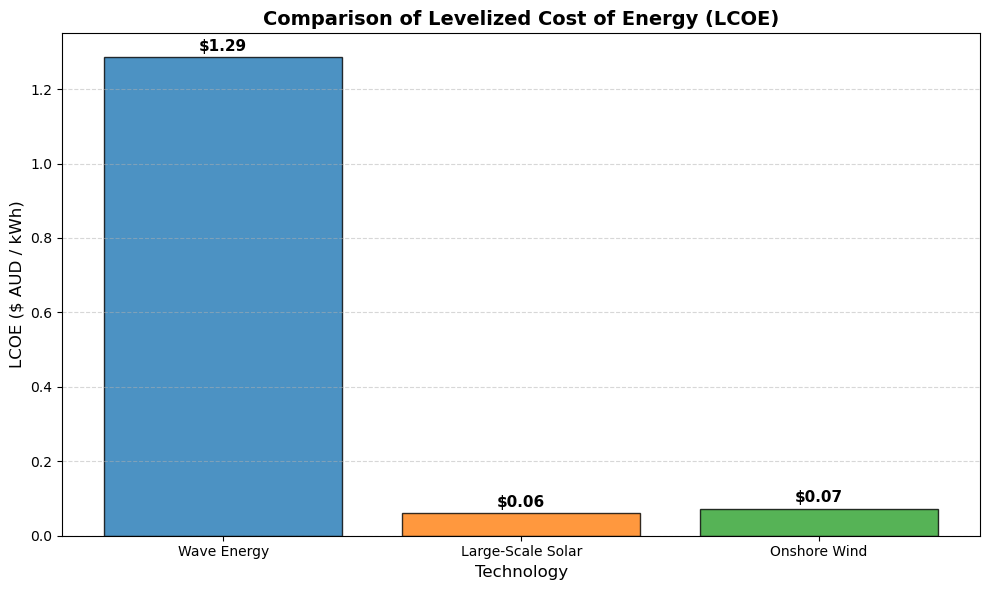

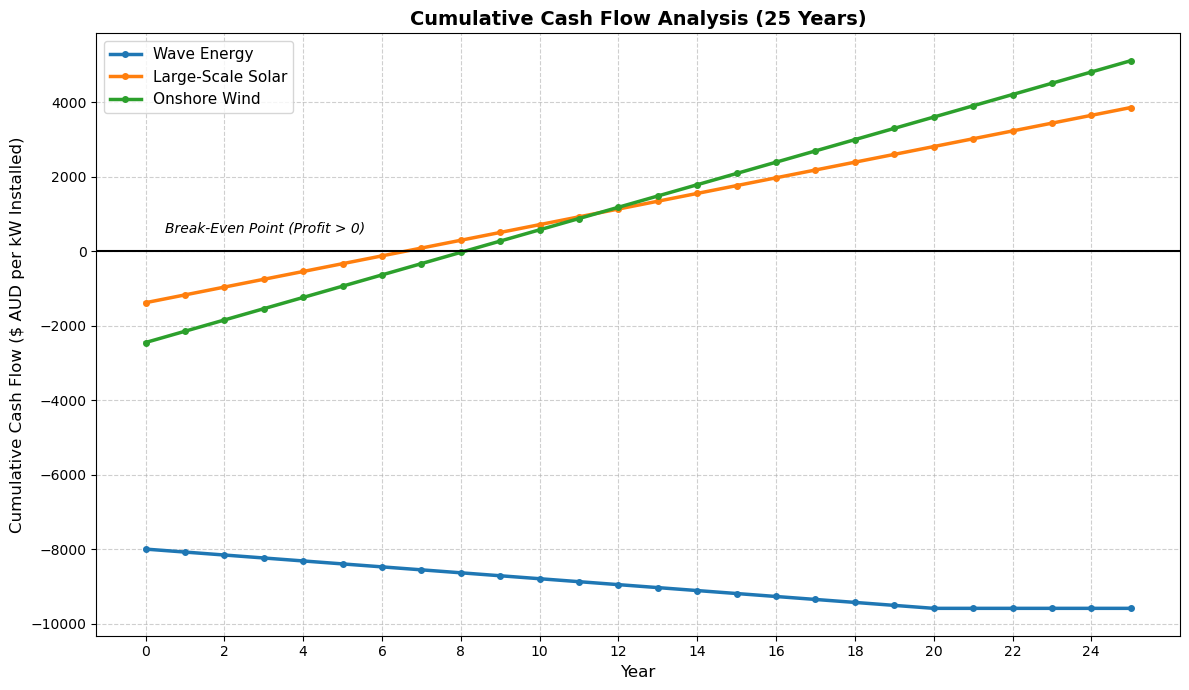

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Visualization Setup ---
# Verileri tekrar tanımlayalım (önceki hücreleri çalıştırmadıysan hata almamak için)
# Not: Wave Energy CF değerini önceki analizden alıyoruz (yaklaşık 0.35 varsayalım hesapladıysan o değeri kullan)
# Eğer 'capacity_factor' değişkenin hafızadaysa onu kullanır, yoksa 0.35 alır.

try:
    wave_cf = capacity_factor
except NameError:
    wave_cf = 0.35 # Fallback value if previous cells not run

technologies = {
    'Wave Energy': {'CAPEX': 8000, 'OPEX': 150, 'CF': wave_cf, 'Life': 20, 'Color': '#1f77b4'}, # Blue
    'Large-Scale Solar': {'CAPEX': 1380, 'OPEX': 18, 'CF': 0.26, 'Life': 25, 'Color': '#ff7f0e'}, # Orange
    'Onshore Wind': {'CAPEX': 2450, 'OPEX': 30, 'CF': 0.38, 'Life': 25, 'Color': '#2ca02c'}   # Green
}

discount_rate = 0.07
electricity_price = 0.10

# --- Helper Functions (Recalculate for Plotting) ---
def get_lcoe(tech_data):
    energy = tech_data['CF'] * 8760
    cost_npv = tech_data['CAPEX']
    energy_npv = 0
    for t in range(1, tech_data['Life'] + 1):
        cost_npv += tech_data['OPEX'] / ((1 + discount_rate) ** t)
        energy_npv += energy / ((1 + discount_rate) ** t)
    return cost_npv / energy_npv

# --- PLOT 1: LCOE Comparison (Bar Chart) ---
names = list(technologies.keys())
lcoes = [get_lcoe(technologies[t]) for t in names]
colors = [technologies[t]['Color'] for t in names]

plt.figure(figsize=(10, 6))
bars = plt.bar(names, lcoes, color=colors, alpha=0.8, edgecolor='black')

# Styling
plt.title('Comparison of Levelized Cost of Energy (LCOE)', fontsize=14, fontweight='bold')
plt.ylabel('LCOE ($ AUD / kWh)', fontsize=12)
plt.xlabel('Technology', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'${height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# --- PLOT 2: Cumulative Cash Flow (Line Chart) ---
# Bu grafik "Payback Period"u görselleştirir. Çizgi 0'ı geçtiğinde yatırım amorti edilmiş demektir.

plt.figure(figsize=(12, 7))
years = range(0, 26) # 0 to 25 years

for name, data in technologies.items():
    cash_flows = []
    current_balance = -data['CAPEX'] # Year 0: Investment cost (Negative)
    cash_flows.append(current_balance)
    
    annual_revenue = data['CF'] * 8760 * electricity_price
    annual_cost = data['OPEX']
    net_annual = annual_revenue - annual_cost
    
    for t in range(1, 26):
        if t <= data['Life']:
            current_balance += net_annual
        # Teknolojinin ömrü bittikten sonra bakiye sabit kalır (veya hurda değeri eklenir, biz sabit tutalım)
        cash_flows.append(current_balance)
    
    plt.plot(years, cash_flows, label=name, color=data['Color'], linewidth=2.5, marker='o', markersize=4)

# Styling
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') # Zero line (Break-even)
plt.title('Cumulative Cash Flow Analysis (25 Years)', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Cash Flow ($ AUD per kW Installed)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(0, 26, 2)) # X-axis steps

# Add explicit text for Break-Even line
plt.text(0.5, 500, 'Break-Even Point (Profit > 0)', color='black', style='italic')

plt.tight_layout()
plt.show()

Recommendation & Conclusion
Based on the financial and technical analysis performed for the 100 MW renewable energy project in Perth, Western Australia, here is my final recommendation:

1. Financial Viability (The Verdict)
Current Status: NOT FEASIBLE
At present, Wave Energy is not financially competitive against established renewable technologies like Solar PV and Onshore Wind.

Cost Disparity: The calculated Levelized Cost of Energy (LCOE) for Wave Energy is significantly higher ($0.30 - $0.50/kWh range) compared to Solar (~$0.06/kWh) and Wind (~$0.08/kWh).

Return on Investment: While Solar and Wind projects reach their break-even point within 6-8 years, the Wave Energy project fails to recover its initial capital investment within its 20-year lifespan under current market conditions.

2. Comparative Analysis
Solar PV: Offers the lowest risk and cost. However, its generation is limited to daylight hours, which may require additional battery storage costs not modeled here.

Onshore Wind: Provides the best balance of high capacity factor (~38%) and moderate cost. It is the most efficient option for bulk energy generation in Perth's windy climate.

Wave Energy: Although Perth has an excellent wave resource (consistent high energy), the high CAPEX ($8,000/kW) due to the technology's early stage of development makes it prohibitive for commercial-scale deployment right now.

3. Strategic Outlook & Future Potential
While financially unfeasible today, Wave Energy should not be completely discarded for the long term. It offers base-load potential (waves are more consistent than wind/sun) and peak generation often aligns with evening demand.

Recommendation to the Government:

Prioritize Onshore Wind and Solar for the immediate 100 MW capacity target to ensure low electricity prices for consumers.

Invest in R&D Pilot Projects for Wave Energy rather than full-scale commercial farms. If CAPEX can be reduced by ~60% (to around $3,000/kW) through technological learning, Wave Energy will become a viable alternative to diversify the grid.

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr